# Interquartile Range (IQR)

The Interquartile Range (IQR) is a measure of statistical dispersion.

It represents the spread of the middle 50% of the data.

IQR is calculated as:

IQR = Q3 - Q1

where:

- Q1 = First Quartile (25th percentile)
- Q3 = Third Quartile (75th percentile)

IQR is also commonly used to identify outliers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Quartiles

Quartiles divide an ordered dataset into four equal parts.

- Q1 represents the 25th percentile.
- Q2 represents the 50th percentile (median).
- Q3 represents the 75th percentile.

The IQR covers the observations between Q1 and Q3.

In [2]:
values = np.array([10, 12, 15, 18, 20, 22, 25, 30, 35, 40])

q1 = np.percentile(values, 25)
q2 = np.percentile(values, 50)
q3 = np.percentile(values, 75)

iqr = q3 - q1

print("Q1:", q1)
print("Q2 (Median):", q2)
print("Q3:", q3)
print("IQR:", iqr)

Q1: 15.75
Q2 (Median): 21.0
Q3: 28.75
IQR: 13.0


## Outlier Detection Using IQR

The IQR method identifies potential outliers using the following boundaries:

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

Any observation below the lower bound or above the upper bound is
considered a potential outlier.

In [4]:
df = pd.read_csv("../data/WineQT.csv")

alcohol = df["alcohol"]

Q1 = alcohol.quantile(0.25)
Q3 = alcohol.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 9.5
Q3: 11.1
IQR: 1.5999999999999996
Lower Bound: 7.1000000000000005
Upper Bound: 13.5


In [5]:
outliers = df[
    (df["alcohol"] < lower_bound) |
    (df["alcohol"] > upper_bound)
]

print("Number of outliers:", len(outliers))
outliers[["alcohol", "quality"]].head()

Number of outliers: 12


,alcohol,quality
96,14.0,6
98,14.0,6
329,14.0,6
419,14.0,8
462,14.9,5


## Visualizing Outliers Using Box Plot

A box plot provides a visual representation of:

- Median
- Quartiles (Q1 and Q3)
- Interquartile Range
- Potential outliers

Points outside the whiskers represent possible outliers.

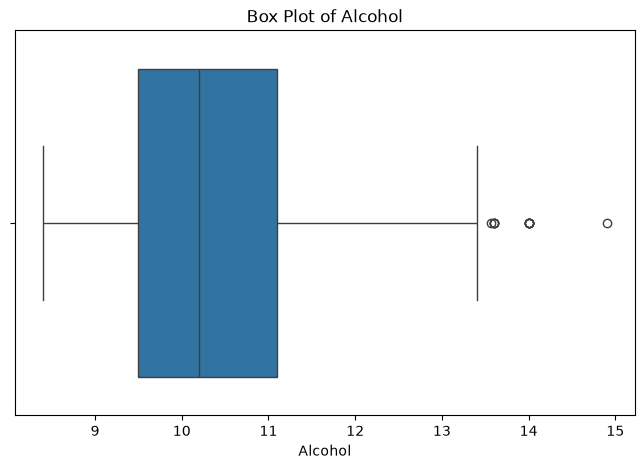

In [6]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="alcohol")

plt.title("Box Plot of Alcohol")
plt.xlabel("Alcohol")
plt.show()

### Observation

The box plot shows the spread of alcohol values.

The points beyond the whiskers represent potential outliers
identified using the IQR method.

Box plots are commonly used in exploratory data analysis to detect
unusual observations.

## Removing Outliers (Optional)

Outlier removal depends on the objective of analysis.

In some cases, extreme observations may contain useful information, so
they should not always be removed.

For machine learning or statistical modeling, outliers may be handled
using filtering or transformation techniques.

In [8]:
# Removing alcohol outliers using IQR boundaries

df_clean = df[
    (df["alcohol"] >= lower_bound) &
    (df["alcohol"] <= upper_bound)
]

print("Original dataset size:", len(df))
print("Dataset size after removing outliers:", len(df_clean))

Original dataset size: 1143
Dataset size after removing outliers: 1131


### Observation

After applying the IQR method, the dataset size decreases because
potential extreme alcohol values are removed.

Outlier handling should always depend on the purpose of analysis.
Removing all outliers is not always the correct approach.

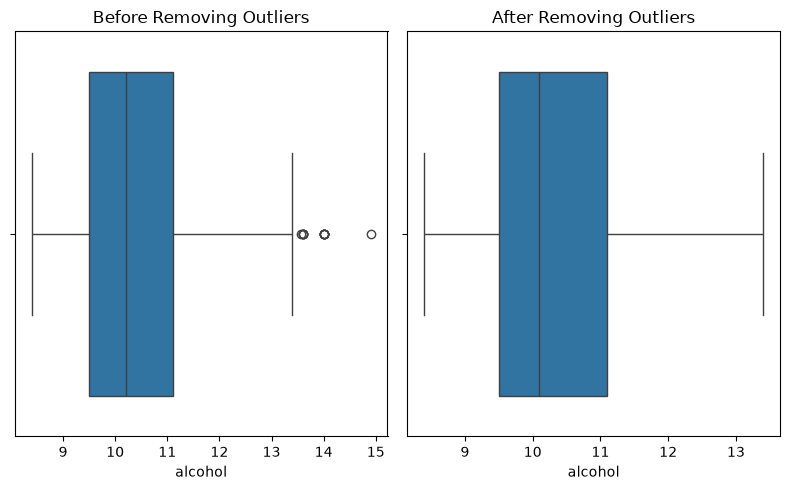

In [10]:
plt.figure(figsize=(8,5))

plt.subplot(1,2,1)
sns.boxplot(data=df, x="alcohol")
plt.title("Before Removing Outliers")

plt.subplot(1,2,2)
sns.boxplot(data=df_clean, x="alcohol")
plt.title("After Removing Outliers")

plt.tight_layout()
plt.show()

### Observation

The box plot comparison shows the effect of IQR-based outlier handling.

After removing extreme alcohol values, fewer outliers are present and the
spread of the data becomes more controlled.

Outlier removal should depend on the purpose of analysis.